In [1]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import scienceplots
import tifffile as tiff

plt.style.use('science')
plt.rcParams["figure.figsize"] = (3.5, 3.5 * ((5**0.5 - 1) / 2)) # 3.5
plt.rcParams["figure.dpi"] = 600
%matplotlib inline

import polars as pl
from polars import Expr, LazyFrame, DataFrame
import numpy as np
from pathlib import Path
from typing import Any
import tifffile
from typing import Dict
from typing import Callable
from boulder_statistics.analysis.quick_calculate import FittingFunction
from boulder_statistics.analysis.data_product_encyclopedia import DataProductEncyclopedia

dp = DataProductEncyclopedia(
    data_products_path=Path(r"C:\Users\Joshu\OneDrive - Nexus365\AO33\Boulder_database\AO33\.data_products"))

In [2]:
fit = FittingFunction(dp, LAD_min=3)

samples = fit.cleaned_data.collect()["alpha"].to_numpy()

In [3]:
from statsmodels.base.model import GenericLikelihoodModel

class TheoryFit(GenericLikelihoodModel):
    param_names = ["e", "g", "q"]

    def __init__(self, x):
        super().__init__(x)

    def loglikeobs(self, params):
        x = self.endog
        print(f"Ran iteration with params {params}")
        return np.log(fit.F_norm(x, *params))

    @property
    def start_params(self):
        return np.array([0.5, 1, 2])
    
mle_model = TheoryFit(samples).fit()

Ran iteration with params [0.5 1.  2. ]


C:\Users\Joshu\AppData\Local\Temp\ipykernel_2952\1765415579.py:12: RuntimeWarning: invalid value encountered in log
  return np.log(fit.F_norm(x, *params))


Ran iteration with params [0.525 1.    2.   ]
Ran iteration with params [0.5  1.05 2.  ]
Ran iteration with params [0.5 1.  2.1]
Ran iteration with params [0.51666667 1.03333333 1.9       ]
Ran iteration with params [0.50416667 1.00833333 2.05      ]
Ran iteration with params [0.5125 1.     2.    ]
Ran iteration with params [0.5   1.025 2.   ]
Ran iteration with params [0.5  1.   2.05]
Ran iteration with params [0.50833333 1.01666667 1.95      ]
Ran iteration with params [0.50208333 1.00416667 2.025     ]
Ran iteration with params [0.50625 1.      2.     ]
Ran iteration with params [0.5    1.0125 2.    ]
Ran iteration with params [0.5   1.    2.025]
Ran iteration with params [0.50416667 1.00833333 1.975     ]
Ran iteration with params [0.50104167 1.00208333 2.0125    ]
Ran iteration with params [0.503125 1.       2.      ]
Ran iteration with params [0.5     1.00625 2.     ]
Ran iteration with params [0.5    1.     2.0125]
Ran iteration with params [0.50208333 1.00416667 1.9875    ]
Ran

KeyboardInterrupt: 

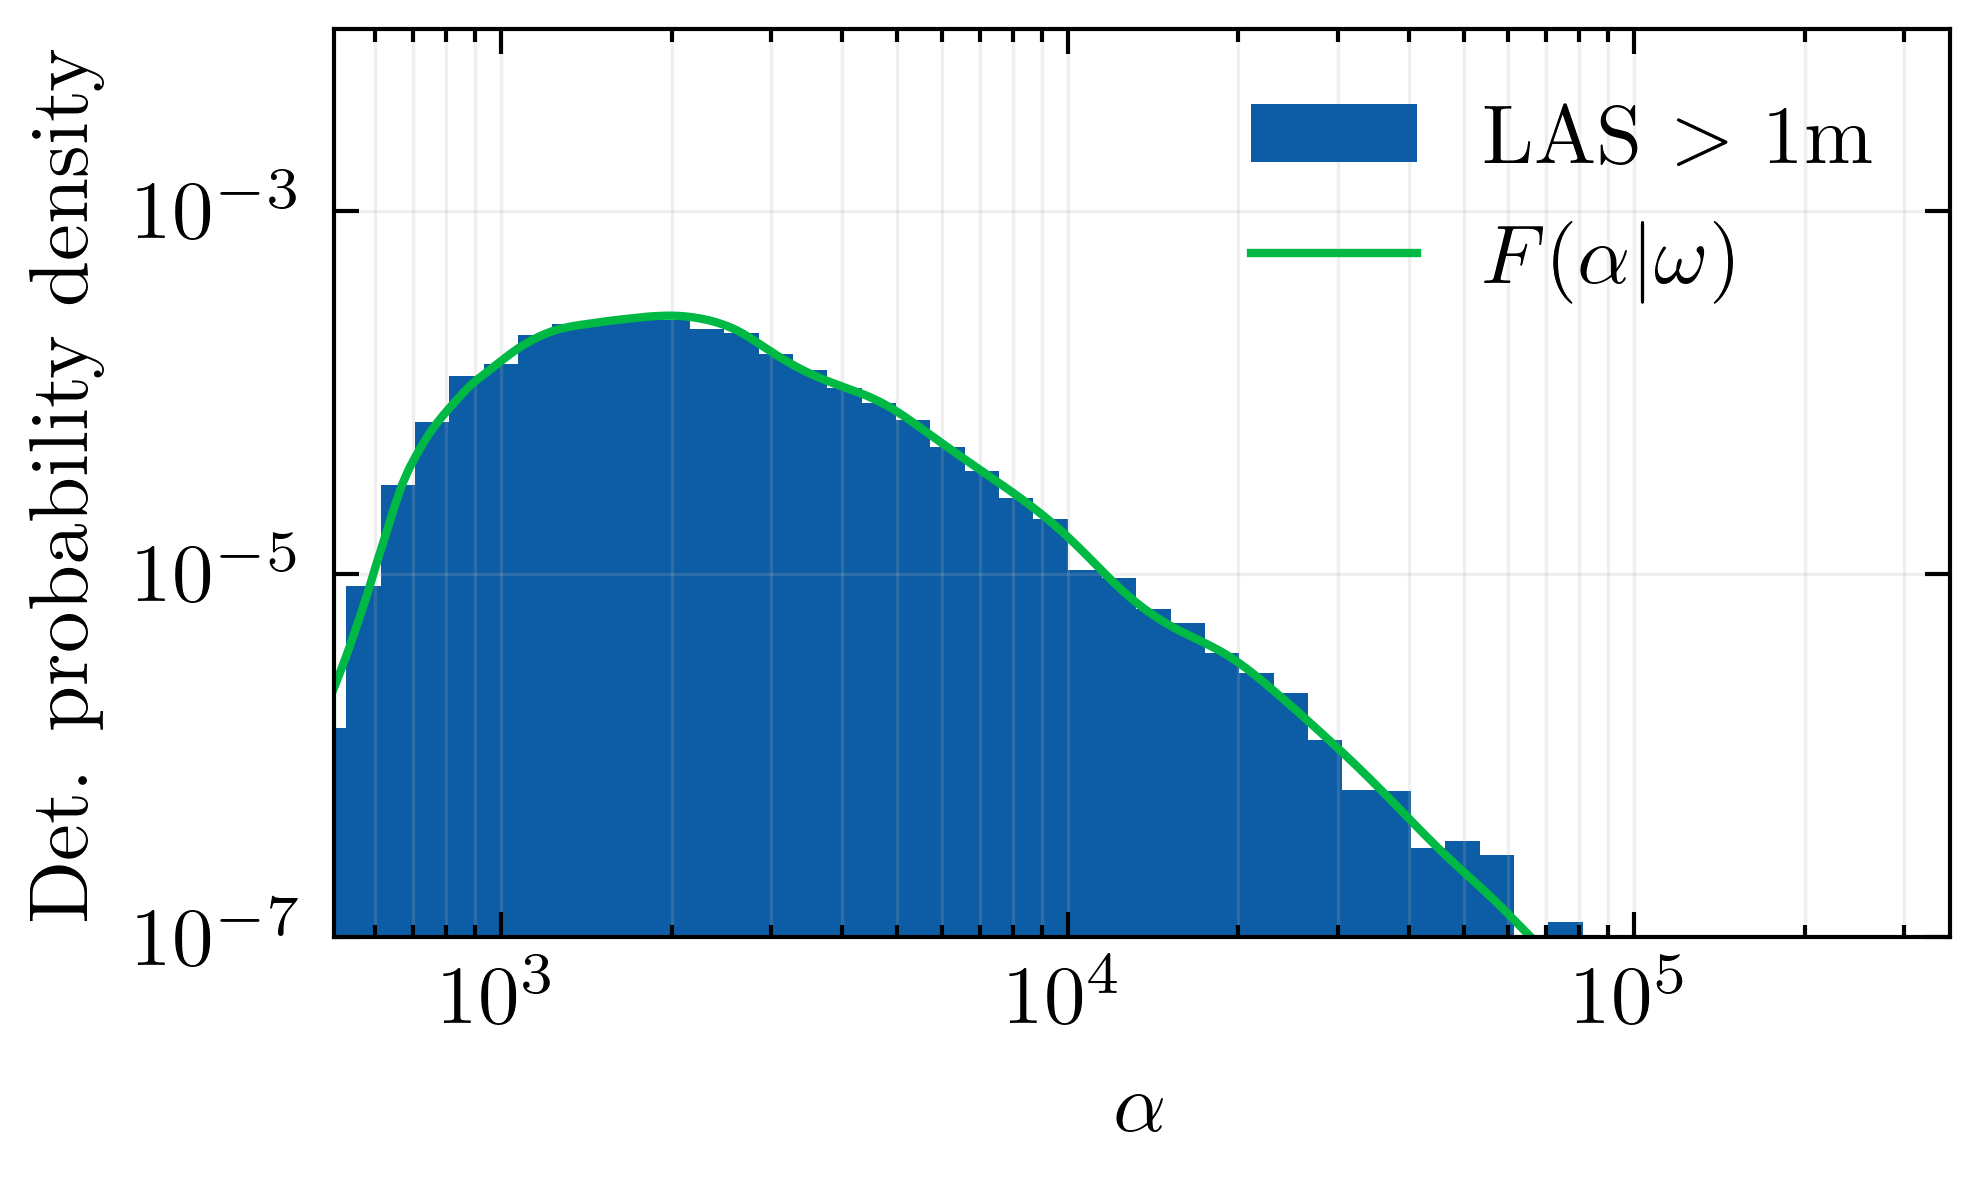

In [ ]:
alphas_hist = np.geomspace(1, 1e6, 100)
alphas = np.geomspace(1, 1e6, 500)

plt.hist(samples, alphas_hist, density = True, label = r"LAS $>$ 1m")

plt.plot(alphas, fit.F_norm(alphas, *mle_model.params), label = r"$F(\alpha|\omega)$")
plt.ylim(1e-7, 1e-2)
plt.xlim(*fit.plot_range)
plt.xscale("log")
plt.xlabel(r"$\alpha$")
plt.yscale("log")
plt.ylabel("Det. probability density")
plt.legend()
plt.grid(which='both', linestyle='-', linewidth=0.4, alpha=0.2)
plt.tight_layout()
plt.savefig("overall_fit.png")
plt.show()

In [ ]:
print(mle_model.summary())
# AIC 1.018e+06 - 1m
# AIC 1.080e5 - 3m

                              TheoryFit Results                               
Dep. Variable:                      y   Log-Likelihood:                -95254.
Model:                      TheoryFit   AIC:                         1.905e+05
Method:            Maximum Likelihood   BIC:                         1.906e+05
Date:                Fri, 24 Apr 2026                                         
Time:                        00:32:49                                         
No. Observations:               10200                                         
Df Residuals:                   10197                                         
Df Model:                           3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
par0           0.5232      0.208      2.514      0.012       0.115       0.931
par1           1.0574      0.000   4183.344      0.0